In [14]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# Define the path to your file
pytorch_file_path = "/mnt/data/dk/work/DeepDocking/projects/pytorch_2RH1/iteration_1/pytorch_hyperparameter_morgan_with_freq_v3.csv"

tensorflow_file_path = "/mnt/data/dk/work/DeepDocking/projects/2RH1/iteration_1/hyperparameter_morgan_with_freq_v3.csv"

# Define column names
columns = [
    "mn",
    "oss",
    "bs",
    "lr",
    "ba",
    "nu",
    "df",
    "wt",
    "cf",
    "auc_vl",
    "pr_vl",
    "Total_left",
    "auc_te",
    "pr_te",
    "re_te",
    "Total_left_te",
    "pos_ct_orig",
]

# Load the CSV file with the defined headers
pth_data = pd.read_csv(pytorch_file_path, header=None, names=columns)
tf_data = pd.read_csv(tensorflow_file_path, header=None, names=columns)

display(pth_data.head())
display(tf_data.head())

,mn,oss,bs,lr,ba,nu,df,wt,cf,auc_vl,pr_vl,Total_left,auc_te,pr_te,re_te,Total_left_te,pos_ct_orig
0,99,10,256,0.0001,2,1500,0.2,3.0,-9.236515,0.907740,0.034247,1.724236e+07,0.906104,0.033853,0.897792,1.726323e+07,4530
1,102,10,256,0.0001,3,1500,0.2,3.0,-9.236515,0.907245,0.033885,1.742680e+07,0.905087,0.033591,0.898896,1.741914e+07,4530
2,100,10,256,0.0001,3,1500,0.2,2.0,-9.236515,0.903271,0.033045,1.786964e+07,0.908134,0.033147,0.908830,1.784778e+07,4530
3,101,10,256,0.0001,2,1500,0.5,2.0,-9.236515,0.914897,0.036557,1.615328e+07,0.917589,0.036480,0.907506,1.619328e+07,4530
4,103,10,256,0.0001,3,1500,0.5,3.0,-9.236515,0.917529,0.038676,1.526802e+07,0.918826,0.038435,0.901545,1.526860e+07,4530


,mn,oss,bs,lr,ba,nu,df,wt,cf,auc_vl,pr_vl,Total_left,auc_te,pr_te,re_te,Total_left_te,pos_ct_orig
0,2,10,256,0.0001,2,1500,0.2,3.0,-9.236515,0.910716,0.035010,1.686670e+07,0.913451,0.035064,0.909713,1.688808e+07,4530
1,7,10,256,0.0001,3,1500,0.5,3.0,-9.236515,0.917159,0.038999,1.514150e+07,0.919802,0.038983,0.910375,1.520167e+07,4530
2,25,10,256,0.0001,2,1500,0.2,3.0,-9.236515,0.913227,0.037344,1.581274e+07,0.913170,0.036958,0.898896,1.583235e+07,4530
3,26,10,256,0.0001,2,1500,0.2,3.0,-9.236515,0.908979,0.034917,1.691174e+07,0.911194,0.034655,0.901987,1.694240e+07,4530
4,27,10,256,0.0001,2,1500,0.2,3.0,-9.236515,0.910053,0.035188,1.678160e+07,0.914719,0.035216,0.909934,1.681940e+07,4530


In [15]:
len(pth_data), len(tf_data)

(24, 37)

# tf_data has some extra rows so we need to drop them and then merge on the same combination of hyperparameters

In [16]:
# Remove duplicates based on the hyperparameter columns in tensorflow data
tf_data_unique = tf_data.drop_duplicates(
    subset=["oss", "bs", "lr", "ba", "nu", "df", "wt"]
)

# Merge the two datasets on the hyperparameter columns
combined_data = pd.merge(
    pth_data,
    tf_data_unique,
    on=["oss", "bs", "lr", "ba", "nu", "df", "wt"],
    suffixes=("_pth", "_tf"),
)

# Select columns for comparison
performance_columns = [
    "cf",
    "auc_vl",
    "pr_vl",
    "Total_left",
    "auc_te",
    "pr_te",
    "re_te",
    "Total_left_te",
    "pos_ct_orig",
]

# Add suffixes to distinguish between the two frameworks
performance_columns_pth = [f"{col}_pth" for col in performance_columns]
performance_columns_tf = [f"{col}_tf" for col in performance_columns]

# Display comparison
for col_pth, col_tf in zip(performance_columns_pth, performance_columns_tf):
    combined_data["difference_" + col_pth.split("_")[0]] = (
        combined_data[col_pth] - combined_data[col_tf]
    )
    comparison = combined_data[[col_pth, col_tf, "difference_" + col_pth.split("_")[0]]]
    print(f"Comparison for {col_pth.split('_')[0]}:")
    display(comparison)
    print("\n")

Comparison for cf:


,cf_pth,cf_tf,difference_cf
0,-9.236515,-9.236515,0.0
1,-9.236515,-9.236515,0.0
2,-9.236515,-9.236515,0.0
3,-9.236515,-9.236515,0.0
4,-9.236515,-9.236515,0.0
5,-9.236515,-9.236515,0.0
6,-9.236515,-9.236515,0.0
7,-9.236515,-9.236515,0.0
8,-9.236515,-9.236515,0.0
9,-9.236515,-9.236515,0.0




Comparison for auc:


,auc_vl_pth,auc_vl_tf,difference_auc
0,0.907740,0.910716,-0.002975
1,0.907245,0.912181,-0.004936
2,0.903271,0.907793,-0.004522
3,0.914897,0.919174,-0.004276
4,0.917529,0.917159,0.000369
5,0.915746,0.918808,-0.003063
6,0.915438,0.920534,-0.005096
7,0.903772,0.908095,-0.004323
8,0.905060,0.910512,-0.005452
9,0.904372,0.909373,-0.005001




Comparison for pr:


...

,re_te_pth,re_te_tf,difference_re
0,0.897792,0.909713,-0.011921
1,0.898896,0.902870,-0.003974
2,0.908830,0.913907,-0.005077
3,0.907506,0.904636,0.002870
4,0.901545,0.910375,-0.008830
5,0.902428,0.907947,-0.005519
6,0.899338,0.907726,-0.008389
7,0.902208,0.917219,-0.015011
8,0.907726,0.905077,0.002649
9,0.903974,0.912362,-0.008389




Comparison for Total:


,Total_left_te_pth,Total_left_te_tf,difference_Total
0,1.726323e+07,1.688808e+07,3.751510e+05
1,1.741914e+07,1.628614e+07,1.133000e+06
2,1.784778e+07,1.759003e+07,2.577506e+05
3,1.619328e+07,1.561192e+07,5.813561e+05
4,1.526860e+07,1.520167e+07,6.692878e+04
5,1.590259e+07,1.516417e+07,7.384157e+05
6,1.556289e+07,1.497262e+07,5.902666e+05
7,1.790512e+07,1.742033e+07,4.847891e+05
8,1.812857e+07,1.672398e+07,1.404583e+06
9,1.793860e+07,1.716153e+07,7.770654e+05




Comparison for pos:


,pos_ct_orig_pth,pos_ct_orig_tf,difference_pos
0,4530,4530,0
1,4530,4530,0
2,4530,4530,0
3,4530,4530,0
4,4530,4530,0
5,4530,4530,0
6,4530,4530,0
7,4530,4530,0
8,4530,4530,0
9,4530,4530,0


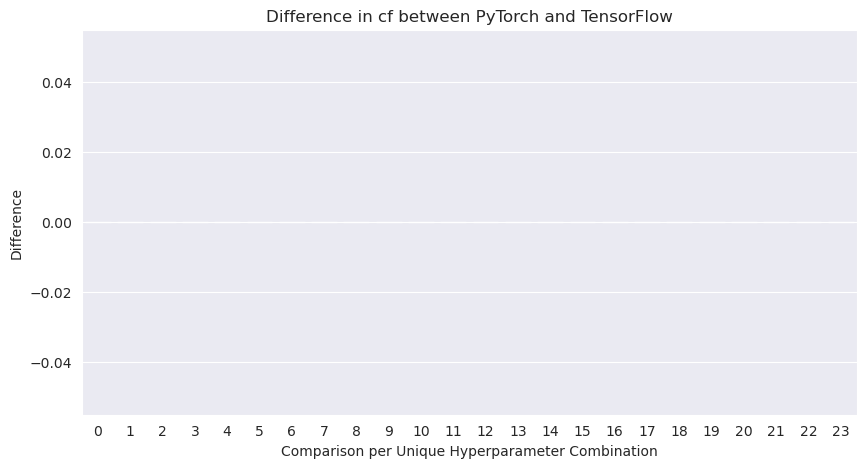

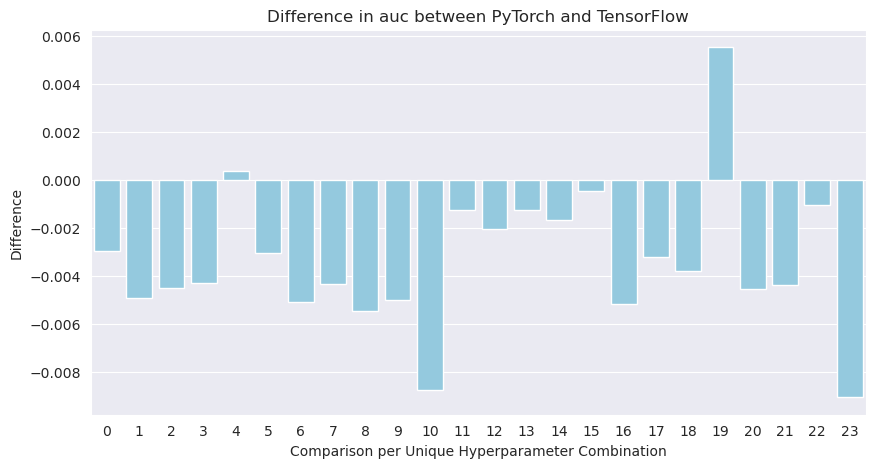

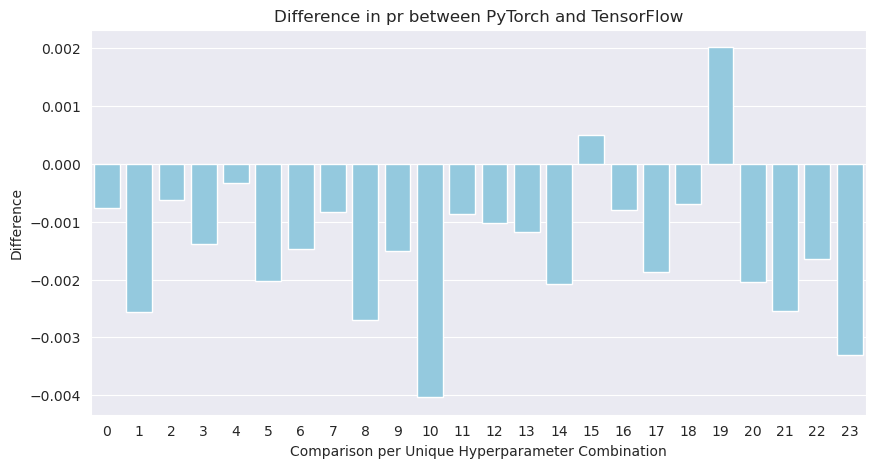

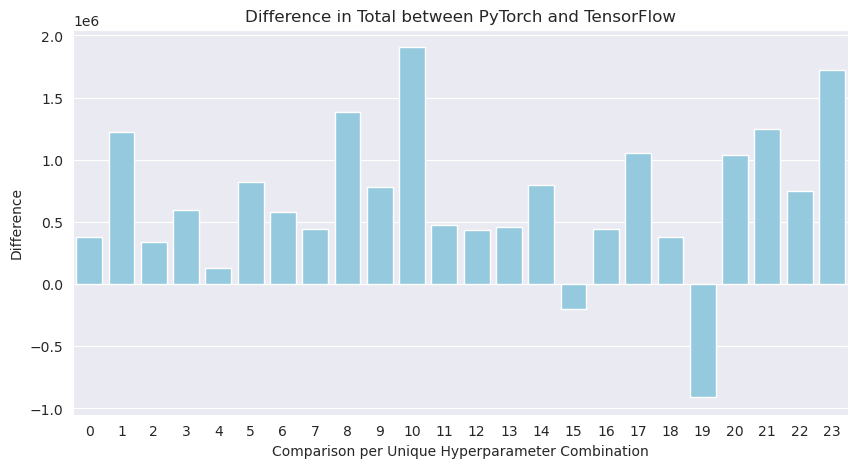

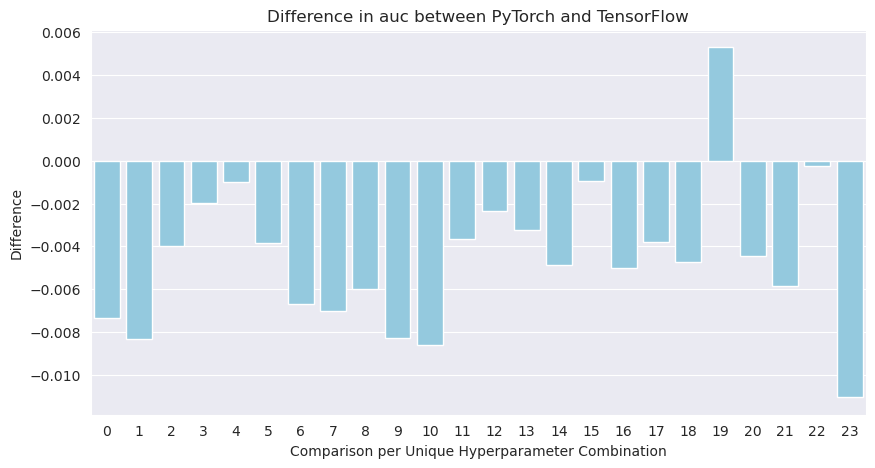

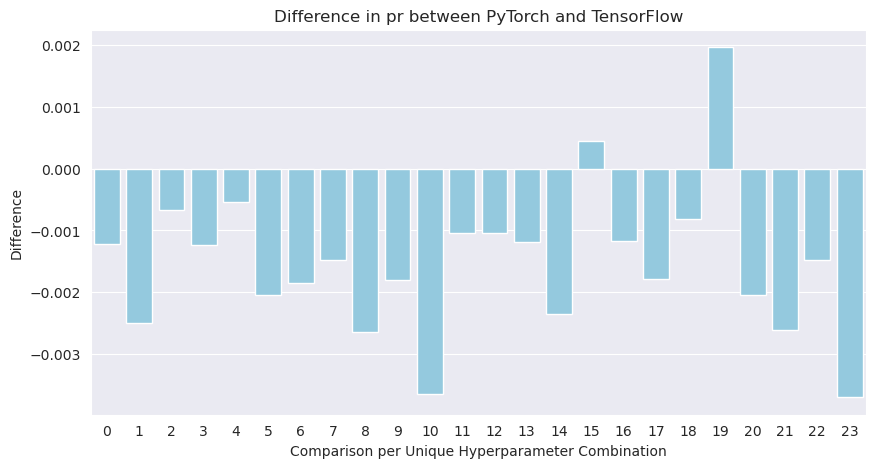

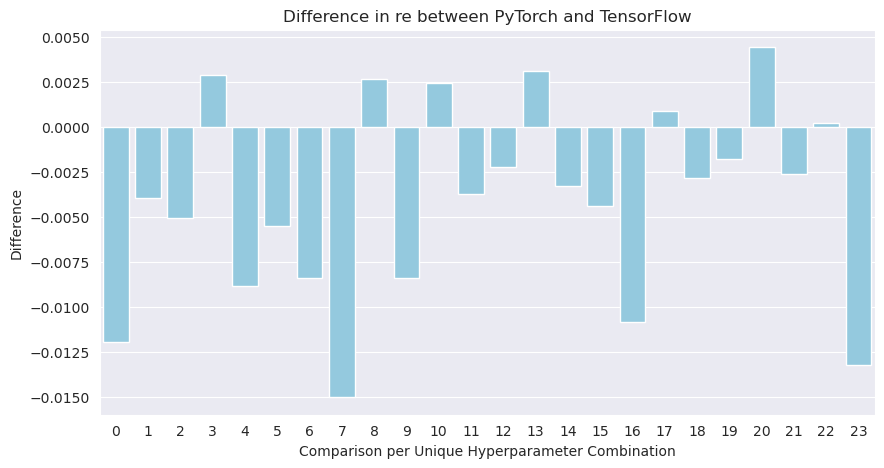

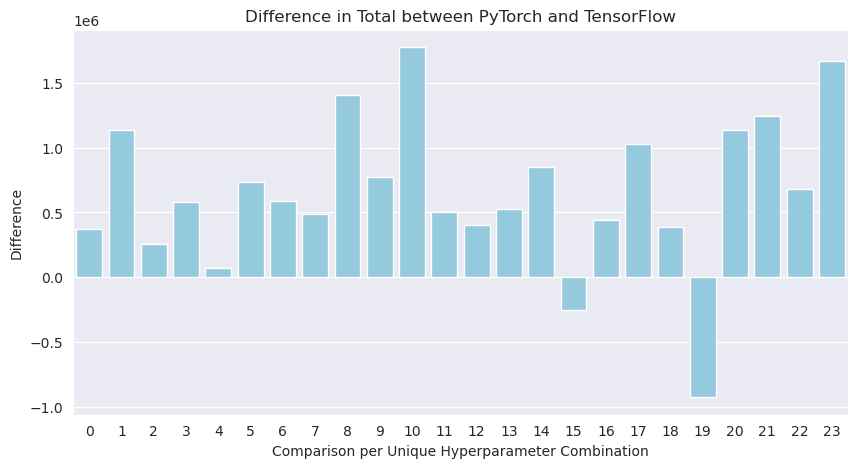

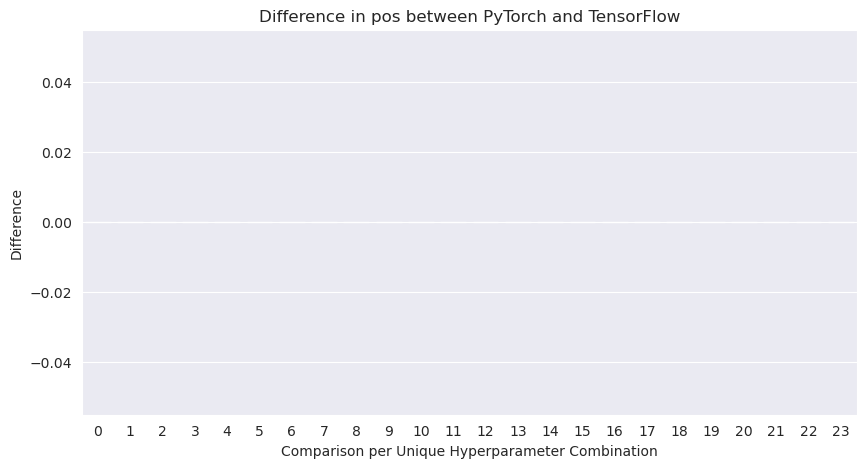

In [17]:
# Set the style to darkgrid
sns.set_style("darkgrid")

# Create bar plots for each comparison
for col_pth, col_tf in zip(performance_columns_pth, performance_columns_tf):
    combined_data["difference_" + col_pth.split("_")[0]] = (
        combined_data[col_pth] - combined_data[col_tf]
    )

    # Plotting
    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=combined_data.index,
        y=combined_data["difference_" + col_pth.split("_")[0]],
        color="skyblue",
    )
    plt.title(f'Difference in {col_pth.split("_")[0]} between PyTorch and TensorFlow')
    plt.xlabel("Comparison per Unique Hyperparameter Combination")
    plt.ylabel("Difference")
    plt.show()